In [12]:
import os
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

data_dir_str: str | None = os.getenv("VF_DATASET_DIR")
if data_dir_str is None:
    raise RuntimeError("VF_DATASET_DIR not defined in environment")

DATA_DIR: Path = Path(data_dir_str)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} does not exist")

files = DATA_DIR.glob("*.parquet")

df = pd.concat(pd.read_parquet(f) for f in files)

print(df.head())
print("cores:", df["core"].unique())
print("rows:", len(df))
print("median sample interval:", df["timestamp"].diff().median())

                   timestamp    t           run_id          source_file  core  \
0    2026-03-10 00:15:14.992  0.0  2026_03_09_2300  2026_03_09_2300.CSV     0   
894  2026-03-10 00:15:14.992  0.0  2026_03_09_2300  2026_03_09_2300.CSV     1   
1788 2026-03-10 00:15:14.992  0.0  2026_03_09_2300  2026_03_09_2300.CSV     2   
2682 2026-03-10 00:15:14.992  0.0  2026_03_09_2300  2026_03_09_2300.CSV     3   
3576 2026-03-10 00:15:14.992  0.0  2026_03_09_2300  2026_03_09_2300.CSV     4   

        vid   clock  eff_clock  temp  power     ppt  cpu_temp  
0     1.105  4951.1    2991.60  51.5  6.226  87.432      58.9  
894   1.110  4846.3    2927.50  52.0  6.741  87.432      58.9  
1788  1.110  4846.3    3185.55  55.0  7.126  87.432      58.9  
2682  1.110  4846.3    2639.80  52.8  6.232  87.432      58.9  
3576  1.090  4901.2    3357.35  55.7  7.601  87.432      58.9  
cores: [0 1 2 3 4 5 6 7]
rows: 706752
median sample interval: 0 days 00:00:00


In [13]:
df_filtered = df[
    (df["eff_clock"] > 2000) &      # ignore idle states
    (df["vid"] > 0.8) &
    (df["power"] > 1)
].copy()

print(len(df_filtered), "rows after filtering")

340077 rows after filtering


Rows after filtering: 100000


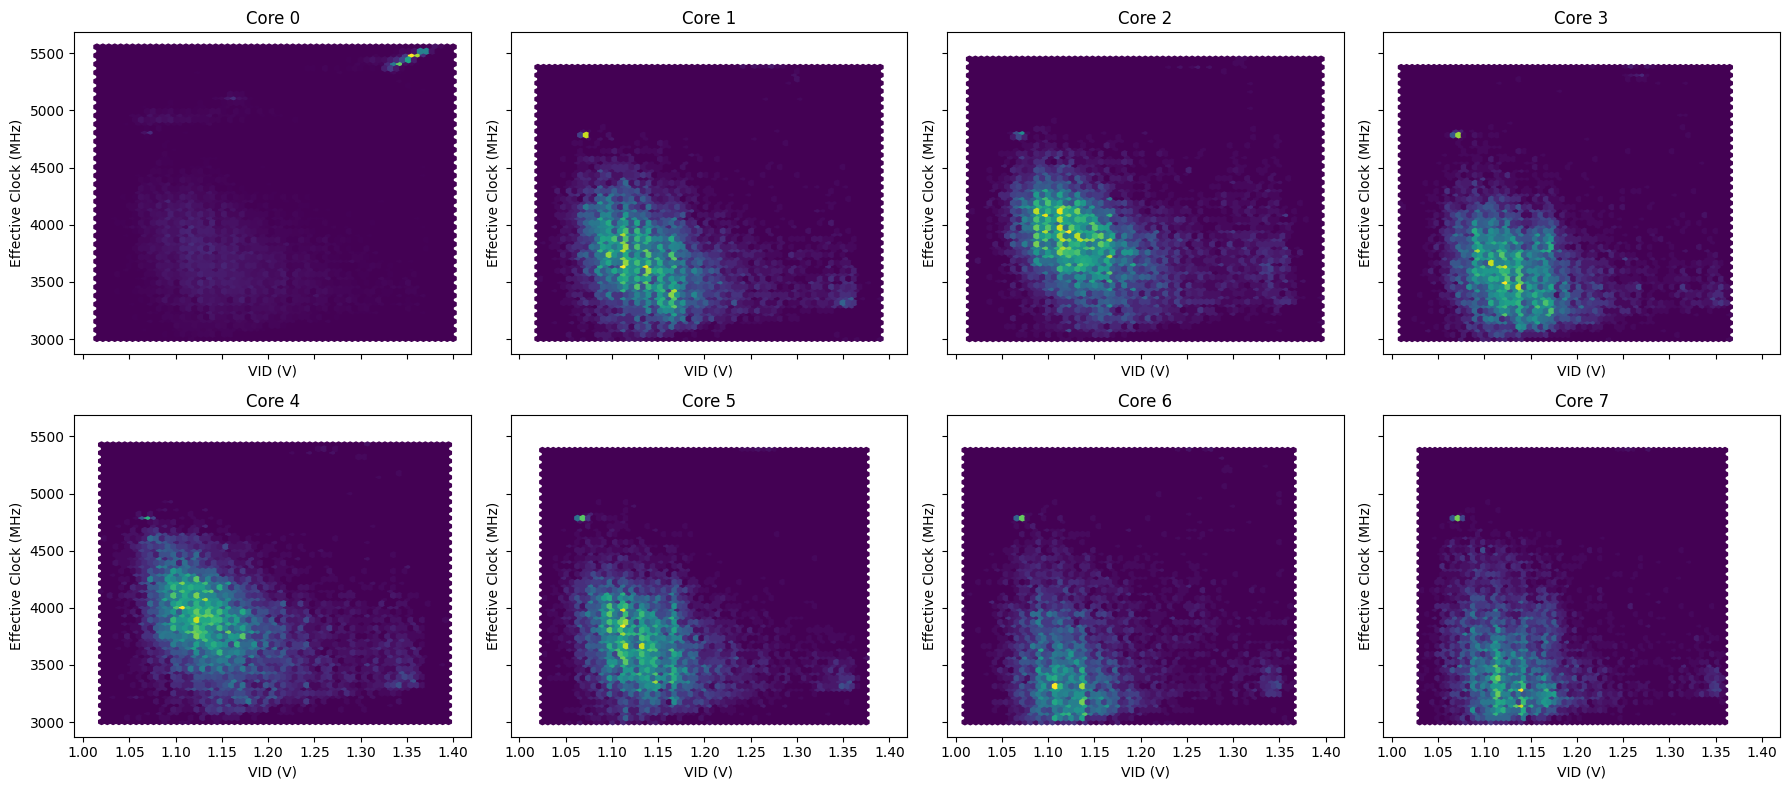

In [14]:
import matplotlib.pyplot as plt
from numpy.ma import power
from dataclasses import dataclass
from typing import Optional


@dataclass
class FilterConfig:
    eff_clock_min: Optional[float] = None
    eff_ratio: Optional[float] = None
    power_min: Optional[float] = None
    vid_min: Optional[float] = None

    def as_dict(self):
        return self.__dict__

def filter_df(df: pd.DataFrame, cfg: FilterConfig) -> pd.DataFrame:

    mask = pd.Series(True, index=df.index)

    if cfg.eff_clock_min is not None:
        mask &= df["eff_clock"] > cfg.eff_clock_min

    if cfg.power_min is not None:
        mask &= df["power"] > cfg.power_min

    if cfg.eff_ratio is not None:
        mask &= df["eff_clock"] > cfg.eff_ratio * df["clock"]

    if cfg.vid_min is not None:
        mask &= df["vid"] > cfg.vid_min

    print("Rows after filtering:", len(df_plot))
    return df[mask].copy()

# filtering parameters
vf_config = FilterConfig(
    eff_clock_min=3000,
    eff_ratio=0.6,
    power_min=4.5,
    vid_min=1.0
)

boost_config = FilterConfig(
    eff_clock_min=4000,
    power_min=8
)

efficiency_config = FilterConfig(
    eff_clock_min=3500,
    power_min=3
)

df_boost = filter_df(df, vf_config)
# optional: speed up plotting

sample_size_target = 200000
def safe_sample(df, n, seed=42):
    return df.sample(min(len(df), n), random_state=seed)

df_plot = safe_sample(df_plot, sample_size_target)


fig, axes = plt.subplots(2, 4, figsize=(18,8), sharex=True, sharey=True)

for core in sorted(df_plot["core"].unique()):

    ax = axes.flat[core]
    d = df_plot[df_plot["core"] == core]

    ax.hexbin(
        d["vid"],          # X = voltage
        d["eff_clock"],    # Y = frequency
        gridsize=60,
        cmap="viridis"
    )

    ax.set_title(f"Core {core}")
    ax.set_xlabel("VID (V)")
    ax.set_ylabel("Effective Clock (MHz)")

plt.tight_layout()
plt.show()

In [15]:
df =df_filtered

boost = df[df["eff_clock"] > 5400]
boost[["core", "vid", "eff_clock", "power", "temp"]].sort_values(
    ["core", "eff_clock"], ascending=[True, False]
).head(20)

boost.groupby("core").agg(
    max_freq=("eff_clock", "max"),
    min_vid=("vid", "min"),
    max_vid=("vid", "max"),
    samples=("eff_clock", "count"),
)

vf_pairs = (
    boost[["core", "vid", "eff_clock"]]
    .round({"vid": 3, "eff_clock": 0})
    .drop_duplicates()
    .sort_values(["core", "eff_clock"])
)

vf_pairs

,core,vid,eff_clock
8371,0,1.330,5400.0
8772,0,1.280,5400.0
9474,0,1.335,5400.0
28620,0,1.340,5400.0
28560,0,1.340,5401.0
...,...,...,...
163834,2,1.315,5444.0
164311,2,1.315,5450.0
163831,2,1.305,5451.0
301681,4,1.310,5427.0


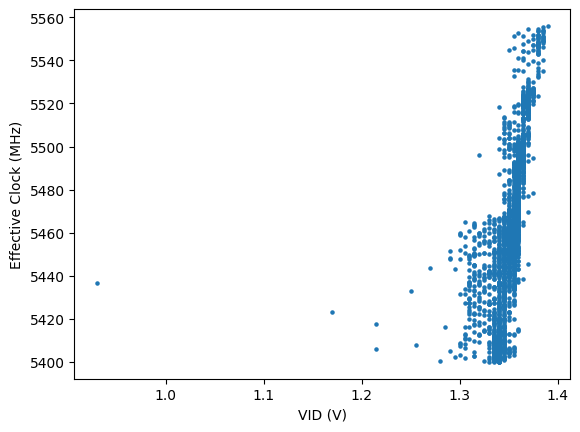

In [16]:
idx = df.groupby("core")["eff_clock"].idxmax()

df.loc[idx, ["core", "eff_clock", "vid", "power", "temp"]]

import matplotlib.pyplot as plt

boost = df[df["eff_clock"] > 5400]

plt.scatter(boost["vid"], boost["eff_clock"], s=5)
plt.xlabel("VID (V)")
plt.ylabel("Effective Clock (MHz)")
plt.show()

In [17]:
df[df["eff_clock"] > 5400]["core"].value_counts().sort_index()

core
0    3862
2       8
4       4
Name: count, dtype: int64

In [18]:
vf_curve = (
    df[df["eff_clock"] > 4000]
    .assign(vbin=lambda x: x["vid"].round(2))
    .groupby(["core", "vbin"])["eff_clock"]
    .max()
    .reset_index()
)